**NOTE: Bolides 2, 8, 12, 13, and 14 have been removed from calculation due to the data quality.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #read in the data as a pandas dataframe

In [3]:
def findtheta(lat, long, alt): #kept here but not actually used in calculations
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom (lat1, long1, lat2, long2, r= 6371000): #haversine equation converts change in latitude/longitude to a distance in meters
    lat1rad = np.radians(lat1) #conversion to radians since our measurements are in degrees
    long1rad = np.radians(long1)
    lat2rad = np.radians(lat2)
    long2rad = np.radians(long2)
    dlat = lat2rad - lat1rad #the difference in latitude
    dlong = long2rad - long1rad #the difference in longitude

    a= np.sin(dlat/2)**2 + np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2 #direct calculation broken into parts
    b= 2*np.arcsin(np.sqrt(a))

    #uncertainty estimation on degtom, each of these 4 lines is representitive of a partial derivitave with respect to that variable 
    errorla1= -r*2*(np.sin(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.cos(dlat/2)*np.sin(dlat/2))/(np.sqrt(1-(np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.sin(dlat/2)**2)**2))
    errorla2= r*2*(np.cos(dlat/2)*np.sin(dlat/2)-np.cos(lat1rad)*np.sin(lat2rad)*np.sin(dlong/2)**2)/(np.sqrt(1-(np.sin(dlat/2)**2+np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2)**2))
    errorlo1= -r*2*(np.cos(lat1rad)*np.cos(lat2rad)*np.cos(dlong/2)*np.sin(dlong/2))/(np.sqrt(1-(np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.sin(dlat/2)**2)**2))
    errorlo2= r*2*(np.cos(lat1rad)*np.cos(lat2rad)*np.cos(dlong/2)*np.sin(dlong/2))/(np.sqrt(1-(np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.sin(dlat/2)**2)**2))
    #this is the errors added in quadrature 
    errordegtom= np.sqrt((errorla1)**2*errorlat**2+(errorla2)**2*errorlat**2+(errorlo1)**2*errorlong**2+(errorlo2)**2*errorlong**2)
    
    
    return r*b, errordegtom

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
    rho0= 1.225 #kg/m^3                   #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [4]:
indexlist= [12, 52, 71, 85, 105, 115, 147, 175, 265, 310] #the index of the bolides being analyzed within bd
satellite= ['g16', 'g16', 'g17', 'g17', 'g17', 'g17', 'g16', 'g16', 'g18', 'g17'] #the satellites each bolide was observed by
rockyradii= [] #empty lists of values we want to find
errorrocky= []
icyradii= []
erroricy= []
metalradii= []
errormetal= []

for i in range(len(indexlist)): #for every bolide we want to analyze...
    bolide= bd.iloc[indexlist[i]] #locating the bolide within the dataframe
    lat= literal_eval(bolide[f'lat_stereo_{satellite[i]}']) #reads the latitude value for this bolide
    long= literal_eval(bolide[f'lon_stereo_{satellite[i]}']) #reads the longitude value
    alt= np.array(literal_eval(bolide[f'alt_stereo_{satellite[i]}']))*1000 #convert the altitude values to meters 
    energy = literal_eval(bolide[f'energyJoules_stereo_{satellite[i]}']) #the energy curve from each bolide

    errorlat= 4000 #we're estimating that the error on latitude and longitude measurements are half a pixel, or 4000 meters
    errorlong= 4000
    erroralt= literal_eval(bolide[f'residual_dist_stereo_{satellite[i]}']) #the error on the altitude is a variable in bd
    
    for i in range(len(energy)):
        if energy[i] == np.max(energy):
            imaxenergy=i #determine the index at which the bolide catastrophically destructs

    totalmass= 0 #these will increase as we sum the steos of our calculation
    totalerror= 0

    for i in range (imaxenergy): #until the bolide catastrophically destructs...
        deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[0] #calculate the distance in meters for each step in latitude/longitude
    
        errordeltalatlong= degtom(lat[i], long[i], lat[i+1], long[i+1])[1]
    
        deltaalt = np.abs(alt[i+1]-alt[i]) #the change in altitude for each step 

        erroralt1= (alt[i]-alt[i+1])/np.abs(alt[i+1]-alt[i]) #partial derivative for error calculation
        erroralt2= (alt[i+1]-alt[i])/np.abs(alt[i]-alt[i+1])
        errordalt= np.sqrt((erroralt1)**2*(erroralt[i])**2+(erroralt2)**2*(erroralt[i+1])**2) #deltaalt errors added in quadrature 
    
        h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
        errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) #the error value for h

        altm = (1/2)*(alt[i]+alt[i+1]) #midpoint altitude for calculating air density
    
        rho = airrho(altm) #air density

        erroraltm= .5*np.sqrt(erroralt[i]**2+erroralt[i+1]**2)
        errorrho= (rho/8500)*erroraltm #the uncertainty on air density

        totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

        terho= (errorrho/rho)**2 
        teh= (errorh/h)**2
        totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder

    rockyradii.append((3/4)*(totalmass/rockyrho)*100) #+- totalerror #units of cm
    metalradii.append((3/4)*(totalmass/metalrho)*100)
    icyradii.append((3/4)*(totalmass/icyrho)*100)

    errorrocky.append((3/4)*(np.sqrt(totalerror)/rockyrho)*100) #uncertainty estimation for each potential bolide
    errormetal.append((3/4)*(np.sqrt(totalerror)/metalrho)*100)
    erroricy.append((3/4)*(np.sqrt(totalerror)/icyrho)*100)

#create a dictionary that can be made into a pandas dataframe
b= {'Index in bolide_data' : indexlist, 'Satellite' : satellite, 'Rocky Bolide Radii' : rockyradii, 'Rocky Bolide Uncertainty' : errorrocky, 'Metal Bolide Radii' : metalradii, 'Metal Bolide Uncertainty' : errormetal, 'Icy Bolide Radii' : icyradii, 'Icy Bolide Uncertainty' : erroricy}
bolide = pd.DataFrame(data=b) #dataframe of all the results

In [5]:
bolide

,Index in bolide_data,Satellite,Rocky Bolide Radii,Rocky Bolide Uncertainty,Metal Bolide Radii,Metal Bolide Uncertainty,Icy Bolide Radii,Icy Bolide Uncertainty
0,12,g16,0.003861,5.373393,0.001802,2.507584,0.018017,25.075835
1,52,g16,0.010168,18.876185,0.004745,8.808886,0.047451,88.088862
2,71,g17,0.000056,0.076412,0.000026,0.035659,0.000262,0.356591
3,85,g17,0.010593,22.948479,0.004943,10.709290,0.049434,107.092900
4,105,g17,0.001213,1.498016,0.000566,0.699074,0.005661,6.990740
5,115,g17,0.021673,58.185592,0.010114,27.153276,0.101142,271.532761
6,147,g16,0.057558,51.128766,0.026861,23.860091,0.268606,238.600910
7,175,g16,0.055958,64.636206,0.026114,30.163563,0.261137,301.635626
8,265,g18,24.068549,40034.271708,11.231990,18682.660130,112.319897,186826.601302
9,310,g17,0.002267,5.772115,0.001058,2.693654,0.010579,26.936536


**GRAPHS**

Text(0.5, 0, 'Bolide Number')

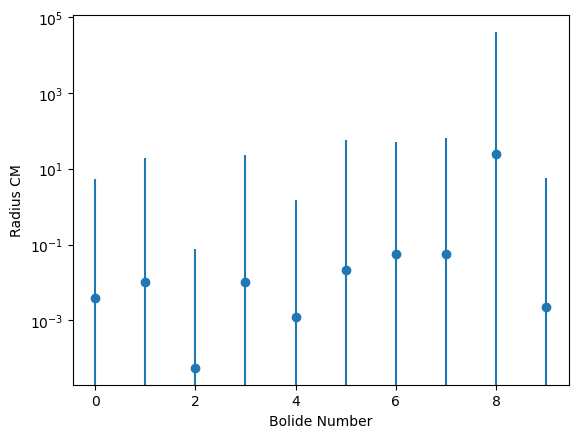

In [6]:
plt.scatter(range(len(bolide['Rocky Bolide Radii'])), bolide['Rocky Bolide Radii'])
plt.errorbar(range(len(bolide['Rocky Bolide Radii'])), bolide['Rocky Bolide Radii'], yerr=bolide['Rocky Bolide Uncertainty'], linestyle='none')
plt.ylabel('Radius CM')
# plt.ylim(0)
plt.yscale('log')
plt.xlabel('Bolide Number')

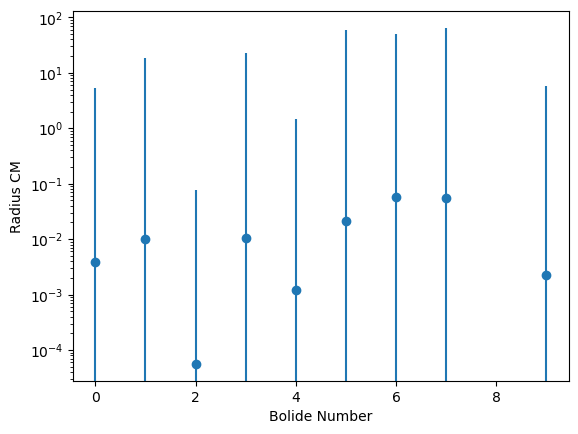

In [7]:
plt.scatter(range(len(bolide['Rocky Bolide Radii'][:8])), bolide['Rocky Bolide Radii'][:8]) #second graph removing the outlier bolide
plt.scatter(range(len(bolide['Rocky Bolide Radii']))[9:], bolide['Rocky Bolide Radii'][9:], c='C0')
plt.errorbar(range(len(bolide['Rocky Bolide Radii'][:8])), bolide['Rocky Bolide Radii'][:8], yerr=bolide['Rocky Bolide Uncertainty'][:8], linestyle='none')
plt.errorbar(range(len(bolide['Rocky Bolide Radii']))[9:], bolide['Rocky Bolide Radii'][9:], yerr=bolide['Rocky Bolide Uncertainty'][9:], c='C0', linestyle='none')
plt.ylabel('Radius CM')
plt.xlabel('Bolide Number')
plt.yscale('log') #the same plot but with the outlier bolide removed